# 03 · Preparación de Datos
### Limpieza · Feature Engineering · Encoding · Split
---
Cada decisión está justificada por un hallazgo del Notebook 02.
El código implementado es exactamente el que usa `src/preprocessing.py`.


In [1]:
import sys, os
ROOT = os.path.abspath('..')
sys.path.insert(0, ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import skew, chi2_contingency
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import DataLoader
from src.preprocessing import ProcesadorDatos

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 110})
COLORS  = ['#4C9BE8', '#F0A500', '#E05A5A']
PALETTE = {'minor': '#4C9BE8', 'major': '#F0A500', 'fatal': '#E05A5A'}

FIGURES = os.path.join(ROOT, 'reports', 'figures')
os.makedirs(FIGURES, exist_ok=True)

def guardar(nombre):
    plt.savefig(os.path.join(FIGURES, nombre), dpi=110, bbox_inches='tight')

loader     = DataLoader(os.path.join(ROOT, 'data', 'indian_roads_dataset.csv'))
df_raw     = loader.cargar_datos()
procesador = ProcesadorDatos()
num_vars   = ['hour','temperature','lanes','vehicles_involved','casualties']


---
## 3.1 Imputación de nulos
**Hallazgo (Notebook 02):** Solo `festival` tiene nulos (99.4%). La ausencia indica que no
había festival ese día. Tomamos la decisión de imputar como categoría `'none'`.


In [2]:
df = procesador.imputar_nulos(df_raw)

display(pd.DataFrame({
    'Variable'      : ['festival'],
    'Nulos antes'   : [int(df_raw['festival'].isnull().sum())],
    '% nulos'       : [round(df_raw['festival'].isnull().mean()*100, 2)],
    'Nulos después' : [0],
    'Acción'        : ['Imputado como "none", la ausencia es informativa']
}).style.set_caption('Resultado de la imputación de nulos').hide(axis='index'))


Variable,Nulos antes,% nulos,Nulos después,Acción
festival,19885,99.420000,0,"Imputado como ""none"", la ausencia es informativa"


---
## 3.2 Verificación: sin outliers, sin transformaciones
**Hallazgo:** 0 outliers por IQR y Z-Score · |skew|<1 en todas las variables.
Como no tenemos outliers no se eliminan registros ni se aplican transformaciones.


In [3]:
rows = []
for c in num_vars:
    Q1, Q3 = df[c].quantile([0.25, 0.75])
    IQR    = Q3 - Q1
    n_iqr  = int(((df[c] < Q1-1.5*IQR) | (df[c] > Q3+1.5*IQR)).sum())
    n_z    = int((np.abs(stats.zscore(df[c])) > 3).sum())
    sk     = round(abs(skew(df[c])), 4)
    rows.append({'Variable':c, 'Outliers IQR':n_iqr, 'Outliers Z-Score':n_z,
                 '|Skew|':sk, 'Requiere transformar':'No' if sk<1 else 'Sí',
                 'Decisión':'Sin acción' if n_iqr==0 else 'Revisar'})

display(pd.DataFrame(rows).style
        .set_caption('Verificación post-imputación — outliers y asimetría').hide(axis='index'))


Variable,Outliers IQR,Outliers Z-Score,|Skew|,Requiere transformar,Decisión
hour,0,0,0.002900,No,Sin acción
temperature,0,0,0.009800,No,Sin acción
lanes,0,0,0.004100,No,Sin acción
vehicles_involved,0,0,0.010600,No,Sin acción
casualties,0,0,0.621800,No,Sin acción


Usamos dos metetos para detectar outliers que son:

* Método IQR: Compar cada valor con un rango normal de cada variable, si este valor esta o por encima o por debajo, si es asi se considera como un outlier. 

* Método Z-SCORE: Este saca un vlaor promedio de las variables y mira si esta lejos de este valor promedio, si es asi es un outlier.

* Skew: Si la distribución está inclinada hacia algun lado. 

Como encontramos que no hay outlier y que hay demasiada simetria y que en cuanto a asimetria no hay ninguna >1 y que el dataset tiene rangos controlados, no fue necesario aplicar transformaciones en los datos. 

Aplicar alguna tranfromacion innecesaria geneeraria ruido y complicaria el modelo. 

---
## 3.3 Feature Engineering — Variables derivadas de riesgo vial

Se crean variables binarias con lógica de negocio e interacciones entre condiciones de riesgo.

| Variable | Lógica | Justificación |
|----------|--------|---------------|
| `night_drive` | hora ≥ 20 o ≤ 5 | Menor visibilidad, mayor fatiga |
| `rush_hour` | 7–9h o 17–19h | Mayor densidad vehicular |
| `bad_weather` | fog o rain | Reduce adherencia y visibilidad |
| `low_vis` | visibility == low | Correlación directa con colisiones |
| `high_traffic` | traffic_density == high | Mayor probabilidad de colisiones |
| `high_risk_cause` | drunk driving / overspeeding | Causas de mayor mortalidad |
| `is_highway` | road_type == highway | Mayor velocidad → mayor severidad |
| `hora_sin / hora_cos` | ciclo 24h | Codificación cíclica de la hora |
| `noche_lluvia` | night × bad_weather | Combinación de riesgo extremo |
| `vis_trafico` | low_vis × high_traffic | Doble factor de riesgo |
| `pico_trafico` | rush_hour × high_traffic | Hora pico con tráfico denso |


Las variables derivadas creadas que tiene relacion con las variables: noche, clima, visibilidad e interacciones del contexto ambiental y conducción. Se apoyan en hallazgos de la literatura que muestran que las condiciones de iluminación y clima si influyen en la severidad de los siniestros.

(Fountas et al., 2020; Ghasemzadeh et al., 2019).

In [4]:
df = procesador.crear_features(df)

binarias = ['night_drive','rush_hour','bad_weather','low_vis',
            'high_traffic','high_risk_cause','is_highway']
interacc = ['noche_lluvia','vis_trafico','pico_trafico']

rows_fe = []
for v in binarias:
    n = int(df[v].sum())
    rows_fe.append({'Variable':v, 'Tipo':'Binaria',
                    'N con valor=1':n, '% del total':round(n/len(df)*100,1)})
for v in interacc:
    n = int(df[v].sum())
    rows_fe.append({'Variable':v, 'Tipo':'Interacción',
                    'N con valor=1':n, '% del total':round(n/len(df)*100,1)})

display(pd.DataFrame(rows_fe).style
        .set_caption('Variables engineered — binarias de riesgo vial e interacciones')
        .hide(axis='index'))


Variable,Tipo,N con valor=1,% del total
night_drive,Binaria,8389,41.900000
rush_hour,Binaria,4945,24.700000
bad_weather,Binaria,13310,66.500000
low_vis,Binaria,9987,49.900000
high_traffic,Binaria,7034,35.200000
high_risk_cause,Binaria,8003,40.000000
is_highway,Binaria,6616,33.100000
noche_lluvia,Interacción,5580,27.900000
vis_trafico,Interacción,3537,17.700000
pico_trafico,Interacción,2780,13.900000


Se realizo ingenieria de variables debido a que las variables originales no ayudaban a encontrar bien el riesgo que se queria capturar.

Se dejaron las variables binarias en pro de encontrar o identificar mejor los riesgos o ciertas variables en especifico para poder mejorar los resultados de los riegos como por ejemplo: 

`night_drive: Hora 2am -> 1 / Hora 2pm -> 0 `

Pero en las de interacción se dejaron como: 

`noche_lluvia: noche x lluvia`

Ya que tanto la hora si influye demasido en el nivel del riesgo del accidente como tambien, si hay noche y hay lluvia  al mismo tiempo se representa como una generacion de mas peligro y las tendencias cambian. 

Tambien se realiza el feature engineering buscando representar condiciones reales que podrían influir en el fenómeno, facilitando el aprendizaje del modelo.

In [5]:
# Chi-cuadrado de variables engineered vs target
rows_chi = []
for c in binarias + interacc:
    tabla = pd.crosstab(df[c], df['accident_severity'])
    chi2, p, _, _ = chi2_contingency(tabla)
    n = tabla.sum().sum()
    v = np.sqrt(chi2 / (n * (min(tabla.shape)-1)))
    rows_chi.append({'Variable':c, 'Chi²':round(chi2,2),
                     'p-valor':round(p,4), 'V Cramér':round(v,4)})

display(pd.DataFrame(rows_chi).style
        .set_caption('Chi-cuadrado — variables engineered vs accident_severity')
        .hide(axis='index'))


Variable,Chi²,p-valor,V Cramér
night_drive,0.490000,0.783900,0.004900
rush_hour,4.850000,0.088300,0.015600
bad_weather,0.240000,0.885400,0.003500
low_vis,0.070000,0.967700,0.001800
high_traffic,1.130000,0.567300,0.007500
high_risk_cause,1.520000,0.468100,0.008700
is_highway,0.330000,0.847700,0.004100
noche_lluvia,0.930000,0.628000,0.006800
vis_trafico,0.780000,0.677900,0.006200
pico_trafico,0.750000,0.688100,0.006100


Se realizo la verificación de las nuevas variables y si estas tiene una relación estadistica con la severidad deñl accidente. 

Se realizo una prueba Chi cuadrado, para verificar si la variable cambia segun la severidad del accidente y con el `P-Valor > 0.05` se obtuvo que las nuevas variables no tiene ninguna relación real.

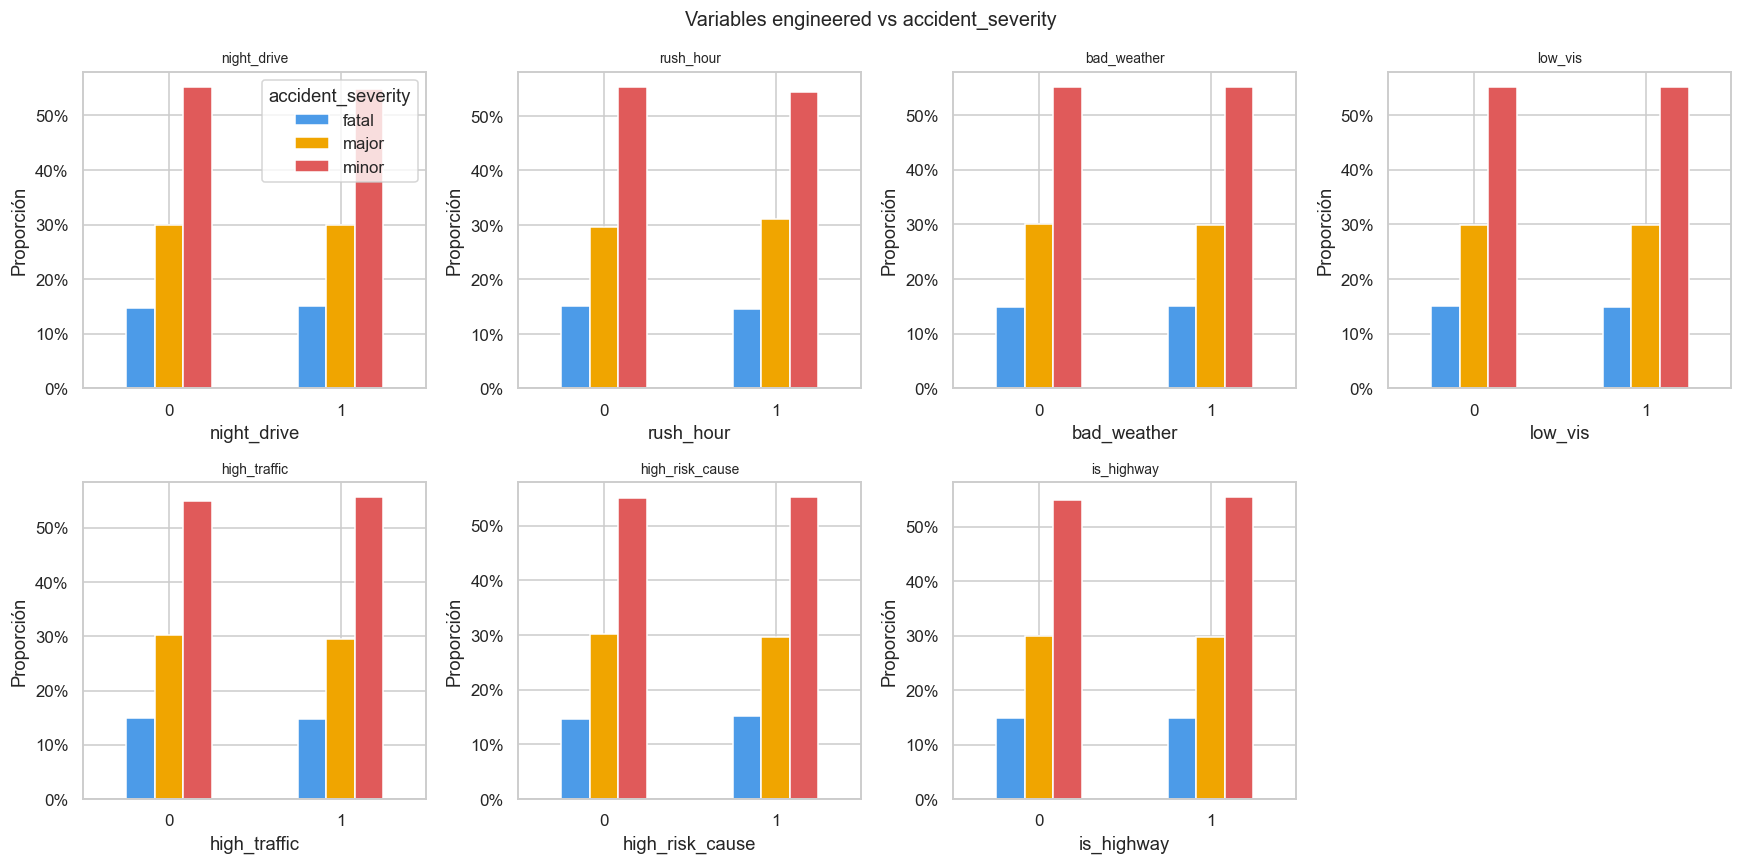

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, var in enumerate(binarias):
    t = df.groupby(var)['accident_severity'].value_counts(normalize=True).unstack()
    t.plot(kind='bar', ax=axes[i], color=COLORS, edgecolor='white',
           rot=0, legend=(i==0))
    axes[i].set_title(var, fontsize=9)
    axes[i].set_ylabel('Proporción')
    axes[i].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[-1].set_visible(False)
plt.suptitle('Variables engineered vs accident_severity', fontsize=13)
plt.tight_layout()
guardar('engineered_vs_target.png')
plt.show()


Se realizo un grafico de las varibles creadas vs la variable severidad del accidente y se evidencio que los resutlados son iguales an ambos donde 0 es no y 1 es si. 

Se evidencio que en la distribucion de los tipos de accidente  las condiciones como conducir de noche o en hora pico y demas, no generar algun cambio insignificante en cuanto a la severidad de los accidentes. 

Por ende, el test Chi cuadrado tiene razon, la severidad del accidente no depende de variables aisladas si no de la conbinacion de estas. 

Por eso combinadas pueden aportar valor en conjunto dentro de modelos que capturan interacciones complejas

---
## 3.4 `risk_score` — VARIABLE

In [7]:
display(df.groupby('accident_severity')['risk_score']
        .agg(Media='mean', Mediana='median', Std='std', Mínimo='min', Máximo='max')
        .round(3).style
        .set_caption('risk_score por clase — leakage de +0.20 en fatales documentado en Notebook 02')
        .background_gradient(cmap='YlOrRd', subset=['Media']))


,Media,Mediana,Std,Mínimo,Máximo
accident_severity,,,,,
fatal,0.608000,0.650000,0.204000,0.300000,1.000000
major,0.407000,0.450000,0.206000,0.100000,0.900000
minor,0.408000,0.450000,0.207000,0.100000,0.900000


Ahora, se buscó el enfoque es esta varible que posee el dataset que va de 0.1 a 1.0 y representa el nivel de riego de cada accidente.

Fue calculado usando la severidad del accidente, por ende es una variable de respuesta de cada accidente sin necesidad de hacer una predicción o sea hay una fuga de datos. 

Se encontro que en cada accidente fatal esta variable tiene 0.20 puntos mas que la formula base. 

Y se percibio como una variable de entrada del dataset al igual que todas las variables, y se usa dentro de la predicción.

Dadonos como resultado y apoyo al notebook 02 que si existe una manipulacion a los datos del dataset. 

---
## 3.5 One-Hot Encoding de variables categóricas
Las variables categóricas no tienen orden implícito (no existe que `fog > rain > clear`). Por eso se usa One-Hot para convertir estas variables a un dato de uso. 


In [8]:
X, y = procesador.preparar_datos(df_raw)

display(pd.DataFrame({
    'Etapa': ['Variables originales (numéricas + engineered)',
              'Después del One-Hot Encoding'],
    'N° columnas': ['Variables base + engineered', X.shape[1]]
}).style.set_caption('Efecto del One-Hot Encoding sobre las features').hide(axis='index'))

grupos = {
    'Numéricas base': [c for c in X.columns
                       if c in ['hour','is_weekend','is_peak_hour','lanes',
                                'temperature','traffic_signal','risk_score']],
    'Engineered (binarias + interacciones)': [c for c in X.columns
                       if c in ['night_drive','rush_hour','bad_weather','low_vis',
                                'high_traffic','high_risk_cause','is_highway',
                                'hora_sin','hora_cos','noche_lluvia','vis_trafico','pico_trafico']],
    'One-hot': [c for c in X.columns
                if any(c.startswith(p) for p in ['road_type_','weather_','visibility_',
                                                  'traffic_density_','cause_','day_of_week_'])]
}
display(pd.DataFrame([
    {'Grupo': k, 'N° variables': len(v), 'Variables': ', '.join(v[:5]) + ('...' if len(v)>5 else '')}
    for k, v in grupos.items()
]).style.set_caption('Grupos de features tras encoding').hide(axis='index'))


Etapa,N° columnas
Variables originales (numéricas + engineered),Variables base + engineered
Después del One-Hot Encoding,43


Grupo,N° variables,Variables
Numéricas base,7,"hour, is_weekend, is_peak_hour, lanes, temperature..."
Engineered (binarias + interacciones),12,"night_drive, rush_hour, bad_weather, low_vis, high_traffic..."
One-hot,24,"road_type_highway, road_type_rural, road_type_urban, weather_clear, weather_fog..."


Se realiza la creacion de estas variables creado una columna por cada una para estas categorias con el fin de tener esas variables utiles. 

---
## 3.6 División Train / Test — 80/20 estratificado

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

rows_split = []
for c in ['minor','major','fatal']:
    rows_split.append({'Clase':c,
                       'Total (%)':round((y==c).sum()/len(y)*100,1),
                       'Train (%)':round((y_train==c).sum()/len(y_train)*100,1),
                       'Test (%)' :round((y_test==c).sum()/len(y_test)*100,1)})

display(pd.DataFrame(rows_split).style
        .set_caption(f'Split 80/20 estratificado — Train: {len(X_train):,} | Test: {len(X_test):,}')
        .hide(axis='index'))


Clase,Total (%),Train (%),Test (%)
minor,55.100000,55.100000,55.100000
major,29.900000,29.900000,30.000000
fatal,14.900000,14.900000,14.900000


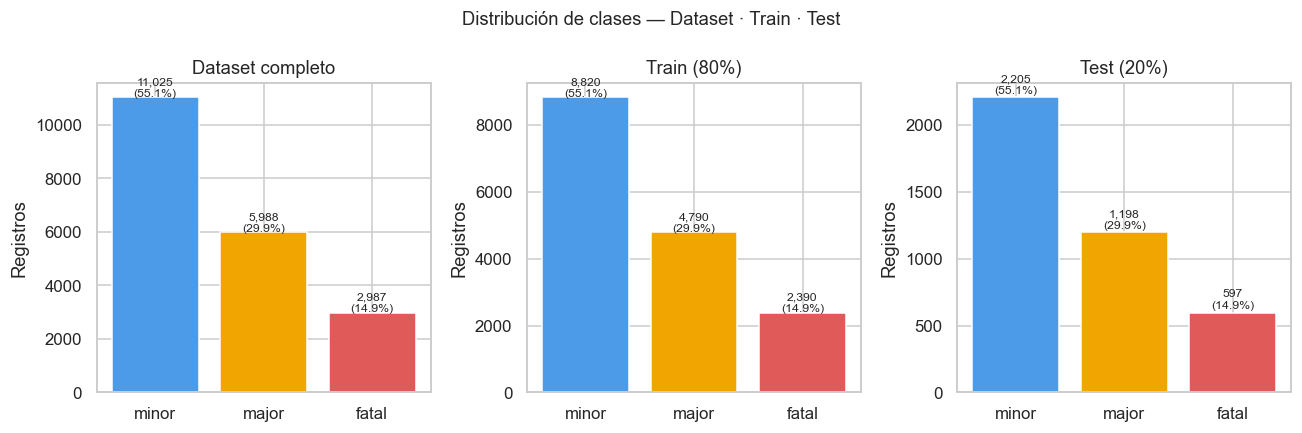

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, datos, titulo in zip(axes, [y, y_train, y_test],
                              ['Dataset completo', 'Train (80%)', 'Test (20%)']):
    conteo = datos.value_counts()
    ax.bar(conteo.index, conteo.values, color=COLORS, edgecolor='white')
    ax.set_title(titulo); ax.set_ylabel('Registros')
    for i, v in enumerate(conteo.values):
        ax.text(i, v+30, f'{v:,}\n({v/len(datos)*100:.1f}%)', ha='center', fontsize=8)
plt.suptitle('Distribución de clases — Dataset · Train · Test', fontsize=12)
plt.tight_layout()
guardar('split_distribucion.png')
plt.show()


Las gráficas muestran que la distribución de las clases se mantiene consistente entre el dataset original, el conjunto de entrenamiento y el de prueba. Esto indica que se realizó un split estratificado correctamente, evitando sesgos y garantizando que el modelo se entrene y evalúe bajo las mismas condiciones

---
## 3.7 Resumen — Trazabilidad Notebook 02 → Notebook 03 → `src/preprocessing.py`

| Hallazgo (Notebook 02) | Decisión (Notebook 03) | Implementación (`preprocessing.py`) |
|------------------------|------------------------|--------------------------------------|
| 0 duplicados | Sin acción | No hay paso de deduplicación |
| `festival` 99.4% nulos | Imputar como `'none'` | `imputar_nulos()` |
| 0 outliers (IQR + Z-Score) | No eliminar registros | No hay filtrado de outliers |
| Skewness < 1 en todas | No transformar | Variables en escala original |
| Chi² no significativo | Mantener categóricas | One-Hot Encoding de todas |
| r=0.55 vehicles↔casualties | Mantener ambas | Ambas en FEATURES |
| `risk_score` leakage | Del CSV, documentado | `if 'risk_score' not in df.columns` |
| Desbalance ratio 3.7x | class_weight='balanced' | En PARAMS de cada modelo |
| Categóricas nominales | One-Hot Encoding | `pd.get_dummies()` en `codificar()` |
| Estratificación necesaria | 80/20 stratify=y | `train_test_split(stratify=y)` |
